- Nicolas Banatt

In [ ]:
!python --version

In [22]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn import metrics

In [24]:
df = pd.read_csv('MergedData_model.csv')

df.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,RRV_label,Baseline_RRVscore
0,6,521.0,252.0,47.0,4.0,0.0,1,0.50
1,10,579.0,229.0,40.0,0.0,0.0,1,0.50
2,6,510.0,102.0,11.0,0.0,0.0,0,0.00
3,10,519.0,117.0,5.0,0.0,0.0,0,0.00
4,10,434.0,300.0,18.0,0.0,0.0,0,0.75


In [25]:
# Split target variable and attributes
attr = df.drop(columns=['RRV_label'])
target = df['RRV_label']

In [26]:
# Separate target into two columns
target=pd.get_dummies(target,prefix='output')
target.head()

,output_0,output_1
0,False,True
1,False,True
2,True,False
3,True,False
4,True,False


In [27]:
# Normalize attributes
scaler = StandardScaler()
attr = pd.DataFrame(scaler.fit_transform(attr), columns=attr.columns)
attr.head()

,Assmnt,Avg_Daily_Sed_Week_Min,Avg_Daily_Light_Week_Min,Avg_Daily_Mod_Week_Min,Avg_Daily_Vig_Week_Min,Avg_Daily_Very_Vig_Week_Min,Baseline_RRVscore
0,-1.042213,-0.450243,0.497972,1.956643,2.342775,-0.168956,-0.492974
1,0.959497,-0.280562,0.207497,1.423586,-0.542475,-0.168956,-0.492974
2,-1.042213,-0.482424,-1.396431,-0.784797,-0.542475,-0.168956,-2.067508
3,0.959497,-0.456094,-1.206991,-1.241704,-0.542475,-0.168956,-2.067508
4,0.959497,-0.704765,1.104181,-0.251739,-0.542475,-0.168956,0.294293


In [28]:
# Split data into training and testing
x_train, x_test, y_train, y_test = train_test_split(attr, target,random_state=86, test_size=0.3)
print(x_train.shape)
print(y_train.shape)

(84, 7)
(84, 2)


In [29]:
# Artificial Neural Network (Multilayer Perceptron)
model = MLPClassifier(hidden_layer_sizes=(5,), max_iter=10000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

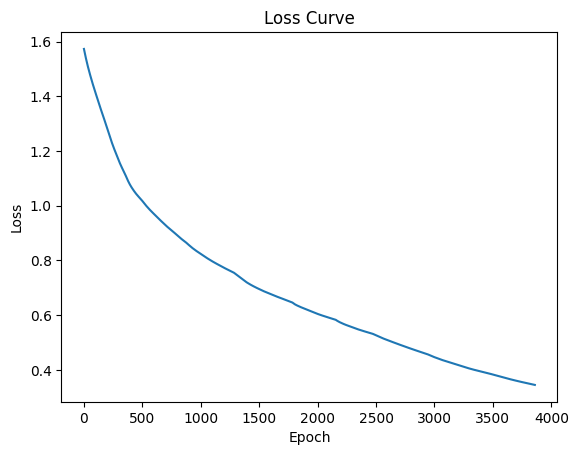

In [30]:
# Plot results
sns.lineplot(x=range(len(model.loss_curve_)), y=model.loss_curve_)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [31]:
# Accuracy Score
accuracy = metrics.accuracy_score(y_pred, y_test)
print("Accuracy: {} ({:.2%})".format(accuracy, accuracy))

Accuracy: 0.7837837837837838 (78.38%)
